---
# Atividade fixação SVM
dupla: *Livia 11261401806* , *Mayte 11241102501*
turma: *6A*

Nessa atividade aplicamos o que aprendemos sobre SVM no dataset Iris dentro desse novo. 

---
# Importação dos dados e bibliotecas
Nessa etapa nós importamos todas as ferramentas (bibliotecas) e utilizariamos durante a analise desses dados sobre cancer de mama. Como já vista, a importação de um dataset no kaggle é diferente do jeito no google colab.
Já nessa etapa retiramos as colunas que não achamos necessárias: Id e Unname. 

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import os
for dirname, _,filenames in os.walk("/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df_cancer = pd.read_csv('/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv')

if 'id' in df_cancer.columns:
    df = df_cancer.drop(columns=['id'])
else:
    df = df_cancer.copy()

df = df.dropna(how='all', axis='columns')

df.head()

/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


---
# Visualização
Aqui pegamos os dados, seus tipos e fizemos as contagens e estatísticas.

In [2]:
# Mostra Linhas e Colunas 
print("Formato dop dataset:", df.shape)
# Informações de tipos de dados e valores (null)
print("\n  Informação das Colunas")
df.info()

# Contagem de cancêr maligno e benigno 
print("\n Contagem por Diagnóstico")
print(df['diagnosis'].value_counts())
# Resumo estatístico das variáveis 
display(df.describe())

Formato dop dataset: (569, 31)

  Informação das Colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se           

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


---
# Histogramas
Aqui vimos a distribuição dos dados tendo como alvo a coluna `diagnosis`

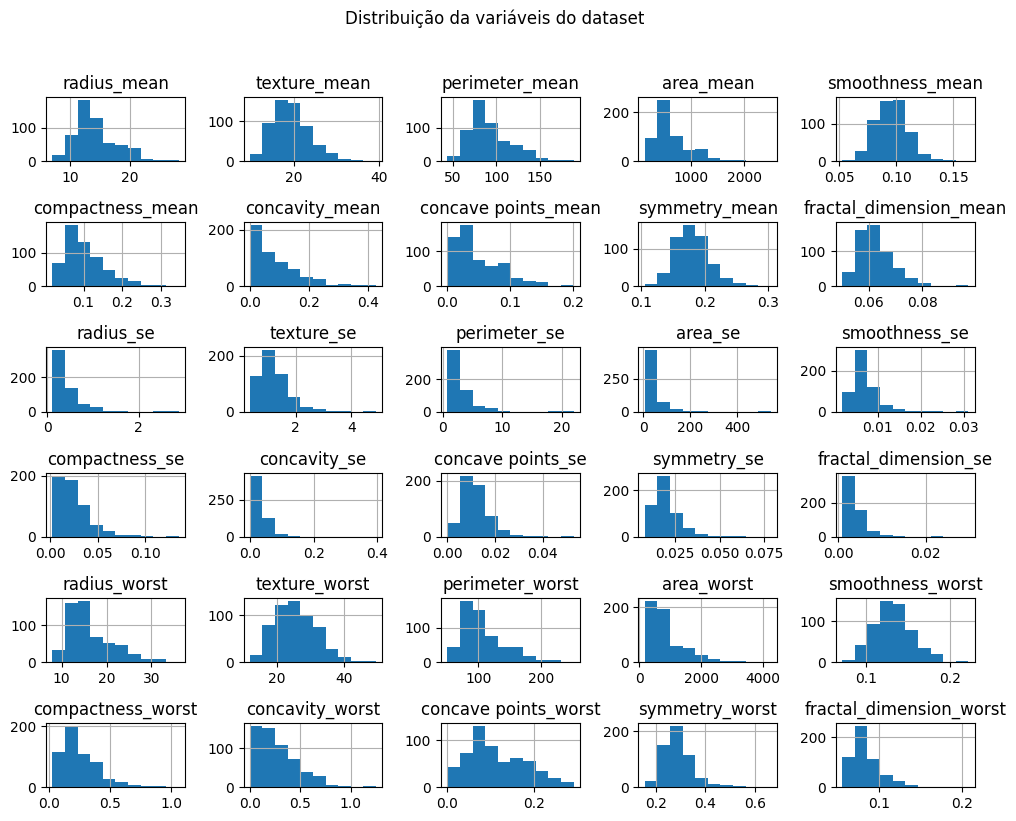

In [3]:
    # Histogramas de Distribuição 
df.drop(columns=['diagnosis']).hist(figsize=(10, 8))
plt.suptitle("Distribuição da variáveis do dataset", y = 1.02)

plt.tight_layout()
plt.show()

---
# Distribuição de testeXtreino
Aqui divimos os dadosa de entrada dos eixos **x** e **y** e os divimos entre o treino e o teste (80x20)

In [4]:
x = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print("Formato de x:", x.shape)
print("Formato de y:", y.shape)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2, 
    random_state = 42, 
    stratify = y
)

print("X_train:", x_train.shape)
print("X_test.shape", x_test.shape)
print("\nDistribuição em y_train:")
print(y_train.value_counts())
print("\nDistribuição em y_test:")
print(y_test.value_counts())

Formato de x: (569, 30)
Formato de y: (569,)
X_train: (455, 30)
X_test.shape (114, 30)

Distribuição em y_train:
diagnosis
B    285
M    170
Name: count, dtype: int64

Distribuição em y_test:
diagnosis
B    72
M    42
Name: count, dtype: int64


---
# Padronização

Aqui a estrutura do pipeline organizada em duas etapas em "scaler" para aplicar a padronização das variáveis de entrada 
Usa o SVM com hiperplano reto, regulariza com C= 1.0 que é um valor padrão, busca uma margem maior aceitando um número pequeno de erros no treino 
O "random_state = 42" garante a mesma reprodutividade em qualquer maquina.

Acurácia do SVM lienar: 0.9649
Relátorio de classificação - SVM linear

              precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



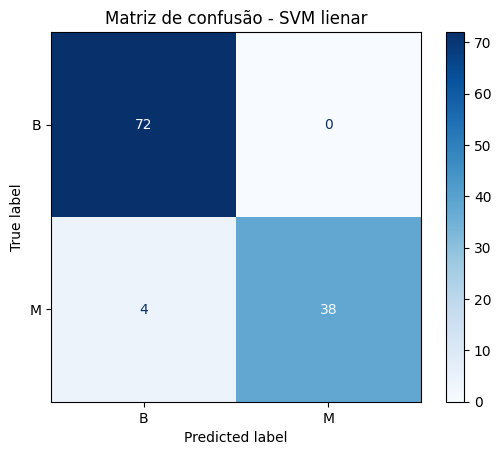

In [5]:
pipeline_svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0, random_state=42))
])

pipeline_svm_linear.fit(x_train, y_train)

y_pred_linear = pipeline_svm_linear.predict(x_test)

acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Acurácia do SVM lienar: {acc_linear:.4f}")

print("Relátorio de classificação - SVM linear\n")
print(classification_report(y_test, y_pred_linear))

classes_cancer = pipeline_svm_linear.classes_

cm_linear = confusion_matrix(y_test, y_pred_linear, labels=classes_cancer)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=classes_cancer)

disp.plot(cmap="Blues")
plt.title("Matriz de confusão - SVM lienar")
plt.show()

---
# Cross validation

Aqui testamos em todas os dados para conferir o modelo SVM

In [6]:
scores_linear = cross_val_score(pipeline_svm_linear, x, y, cv=5)

print("Acurácia em cada fold:", scores_linear)
print(f"Média: {scores_linear.mean():.4f}")
print(f"Desvio-padrão: {scores_linear.std():.4f}")

Acurácia em cada fold: [0.96491228 0.98245614 0.96491228 0.96491228 0.98230088]
Média: 0.9719
Desvio-padrão: 0.0086


---
# Não Linear

Aqui é semelhante ao linear (linhas acima) Mundando apenas o `rbf`(Radial Basis Function, que cria fronteiras de decisão curvas e circulares para separar classes que não podem ser divididas por uma linha reta.) e `gamma`(efine o alcance de influência de cada ponto, `scale` ajusta esse alcance com base na variância)

Acurácia do SVM Não Linear (RBF): 0.9737

Relatório de Classificação — SVM Não Linear (RBF)

              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



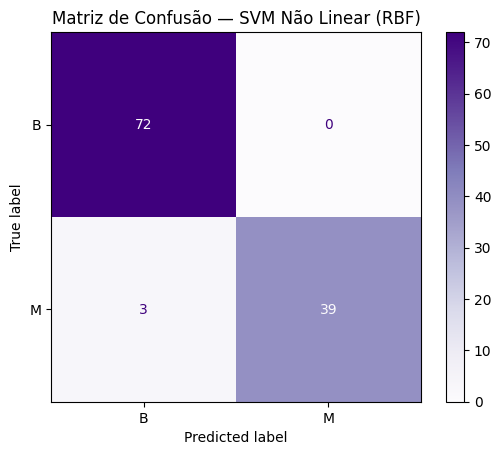

In [7]:
pipeline_svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

pipeline_svm_rbf.fit(x_train, y_train)

y_pred_rbf = pipeline_svm_rbf.predict(x_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Acurácia do SVM Não Linear (RBF): {acc_rbf:.4f}\n")

print("Relatório de Classificação — SVM Não Linear (RBF)\n")
print(classification_report(y_test, y_pred_rbf))

# Matriz de Confusão
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
disp_rbf = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=pipeline_svm_rbf.classes_)

disp_rbf.plot(cmap="Purples")
plt.title("Matriz de Confusão — SVM Não Linear (RBF)")
plt.show()